<a href="https://colab.research.google.com/github/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar/blob/main/entornos_complejos/src/taxi_comparation.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Comparación entre algoritmos en el problema Taxi-v3

*Description:* Comparación experimental de los mejores algoritmos de cada familia en el entorno Taxi-v3.
Se analizan recompensa promedio, longitud de episodio y estabilidad de convergencia bajo política $\epsilon$-greedy con decaimiento.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/22


## Preparación del entorno


In [1]:
import sys
if 'google.colab' in sys.modules:
    # Definimos que el entorno es Colab
    en_colab = True
    print("Ejecutando en Google Colab")
else:
    # Definimos que el entorno es local
    en_colab = False
    print("Ejecutando en entorno local")

if en_colab:
    #@title Copiar el repositorio.
    print("Clonando el repositorio, tiempo estimado: 1-2 minutos...")
    !git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
    !cd EML_Carrillo_Ibarrola_Palomar/

    #@title Importamos todas las clases y funciones
    # Añadir los directorio fuentes al path de Python
    sys.path.append('/content/EML_Carrillo_Ibarrola_Palomar/entornos_complejos/src/')
    # Verificar que se han añadido correctamente
    print(sys.path)

    !pip install -r ./EML_Carrillo_Ibarrola_Palomar/requirements.txt

    dir_base = "./EML_Carrillo_Ibarrola_Palomar/entornos_complejos"
else:
    dir_base = ".."

Ejecutando en entorno local


In [ ]:
import gymnasium as gym
import numpy as np

from tqdm import tqdm  # Progress bar

from utils import plot_training_metrics, plot_training_metrics_multi, save_state, save_training_metrics, load_training_metrics

# Garantizamos reproducibilidad
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Experimento Final: Comparación Global (Q-Learning vs SARSA vs Montecarlo)

En los notebooks anteriores hemos explorado y optimizado de manera independiente tres familias de algoritmos fundamentales en el Aprendizaje por Refuerzo para resolver el entorno **Taxi-v3**:

1. **Q-Learning (Off-Policy TD):** Mostró un buen rendimiento, convergiendo a la política óptima en apenas 2000 episodios.
2. **Expected SARSA (On-Policy TD):** Demostró ser una variante muy robusta y estable, logrando buenos resultados en unos 4000 episodios.
3. **Montecarlo Off-Policy:** Aunque superó ampliamente a su contraparte On-Policy, requirió unos 20000 episodios para alcanzar un rendimiento comparable al de los métodos de Diferencia Temporal (TD).

En este experimento final, vamos a cargar las métricas de entrenamiento (recompensas, longitudes de episodio y error diferencial) de los mejores agentes de cada familia y las graficaremos juntas. Esto nos permitirá visualizar de forma directa las diferencias en velocidad de convergencia y estabilidad entre los enfoques que actualizan paso a paso (TD) y los que actualizan al final del episodio (Montecarlo).

In [ ]:
# Rutas a los archivos generados en los notebooks anteriores
path_qlearning = dir_base + "/data/results/QLearning/experiment1_metrics.npz"
path_sarsa = dir_base + "/data/results/expectedSARSA/expectedSARSA_metrics.npz"
path_mc = dir_base + "/data/results/montecarlo/mc_off_policy_metrics.npz"

try:
    # Cargamos las métricas usando la función de utils
    q_rewards, q_lengths, q_errors = load_training_metrics(path_qlearning)
    sarsa_rewards, sarsa_lengths, sarsa_errors = load_training_metrics(path_sarsa)
    mc_rewards, mc_lengths, mc_errors = load_training_metrics(path_mc)
    print("Métricas cargadas correctamente.")
except FileNotFoundError as e:
    print(f"Error al cargar los archivos. Asegúrate de haber ejecutado y guardado las métricas de los 3 notebooks anteriores.\n{e}")

Métricas cargadas correctamente.


### Visualización de las curvas de aprendizaje

A continuación, utilizamos la función `plot_training_metrics_multi` para superponer las métricas. Hay que tener en cuenta que los agentes de Q-Learning y SARSA se entrenaron durante muchos menos episodios (2000 y 4000 respectivamente) en comparación con Montecarlo (20000). 

Para que la gráfica sea legible, se aplicará una media móvil. La gráfica de los métodos TD terminará antes en el eje X (episodios).

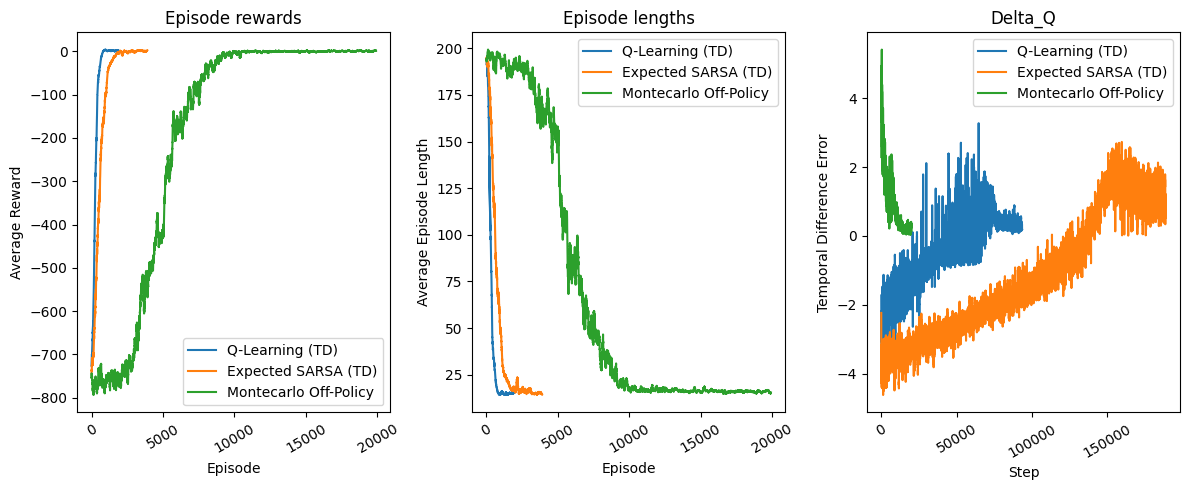

In [4]:
# Preparamos las listas para la función plot_training_metrics_multi
rewards_list = [q_rewards, sarsa_rewards, mc_rewards]
lengths_list = [q_lengths, sarsa_lengths, mc_lengths]
errors_list = [q_errors, sarsa_errors, mc_errors]

# Etiquetas para la leyenda
labels = ["Q-Learning (TD)", "Expected SARSA (TD)", "Montecarlo Off-Policy"]

# Mostramos la comparativa (usamos una ventana de suavizado de 100 episodios para ver bien las tendencias)
plot_training_metrics_multi(
    rewards_list=rewards_list,
    lengths_list=lengths_list,
    training_errors_list=errors_list,
    labels=labels,
    rolling_length=100,
    isMonteCarlo=False # Lo dejamos en False para mantener la escala lineal en el error (Delta Q)
)

## Conclusiones

Al analizar las gráficas comparativas, podemos extraer varias conclusiones fundamentales sobre cómo operan estos algoritmos en entornos discretos como **Taxi-v3**:

1. **Diferencias Temporales (TD) vs Montecarlo:** La diferencia más notable es la **eficiencia de muestreo**. Q-Learning y Expected SARSA convergen a la política óptima en una fracción del tiempo (y episodios) que necesita Montecarlo. Esto se debe al *bootstrapping*: los métodos TD actualizan sus estimaciones de valor en cada paso $t$, aprovechando la información del siguiente estado $S_{t+1}$ sin esperar a que el episodio termine. Como en este entorno hay penalizaciones por paso (-1) y las recompensas finales están "lejos", aprender paso a paso es una gran ventaja.

2. **La alta varianza de Montecarlo:**
   Montecarlo requiere explorar trayectorias completas hasta el final antes de realizar una sola actualización. Al inicio, cuando la política es mayormente aleatoria, los episodios alcanzan el límite máximo de pasos (200) y devuelven retornos muy ruidosos y negativos. Esta alta varianza hace que el aprendizaje sea muy lento, necesitando decenas de miles de episodios para estabilizar los valores $Q$.

3. **Q-Learning vs Expected SARSA:**
   Ambos algoritmos TD muestran un rendimiento excelente. 
   * **Q-Learning** es optimista al utilizar el operador máximo ($\max_{a'} Q(s', a')$) para actualizar sus estimaciones. 
   * **Expected SARSA**, al considerar la media de las acciones futuras basándose en la política actual, es ligeramente más conservador y suave en su curva de aprendizaje, pero igual de efectivo al final del entrenamiento.

Para el problema de Taxi-v3, los algoritmos basados en **Diferencias Temporales (TD)**, en particular **Q-Learning**, son claramente la mejor opción.